In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cleaned visa dataset.xlsx to cleaned visa dataset.xlsx


In [ ]:
import pandas as pd

# ==========================================
# STEP 1: LOAD EXCEL FILE
# ==========================================

excel_file = "cleaned visa dataset.xlsx"  # Name of uploaded file

df = pd.read_excel(excel_file)

print("Excel Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

# ==========================================
# STEP 2: CHECK COLUMN NAMES
# ==========================================

print("\nColumns in Dataset:")
print(df.columns)

# ==========================================
# STEP 3: REMOVE ROWS WITH MISSING DATES
# ==========================================

df = df.dropna(subset=["case_received_date", "decision_date"])

print("\nAfter Removing Missing Dates:", df.shape)

# ==========================================
# STEP 4: CONVERT DATE COLUMNS TO DATETIME
# ==========================================

df["case_received_date"] = pd.to_datetime(df["case_received_date"], errors="coerce")
df["decision_date"] = pd.to_datetime(df["decision_date"], errors="coerce")

df = df.dropna(subset=["case_received_date", "decision_date"])

print("After Date Conversion:", df.shape)

# ==========================================
# STEP 5: CALCULATE PROCESSING DAYS AND CLEAN UP
# ==========================================
df["processing_days"] = (df["decision_date"] - df["case_received_date"]).dt.days

# Remove the original 'Processing Day' column if it exists, to avoid confusion
if "Processing Day" in df.columns:
    df = df.drop(columns=["Processing Day"])

# ==========================================
# STEP 6: REMOVE DUPLICATES
# ==========================================

df = df.drop_duplicates()

print("After Removing Duplicates:", df.shape)


# ==========================================
# STEP 7: SAVE CLEAN DATASET
# ==========================================

output_file = "perm_final_clean.csv"
df.to_csv(output_file, index=False)

print("\nDONE! Clean dataset saved successfully.")
print("File saved as:", output_file)


Excel Dataset Loaded Successfully!
Dataset Shape: (1000, 15)

Columns in Dataset:
Index(['case_received_date', 'case_status', 'class_of_admission',
       'country_of_citizenship', 'decision_date', 'employer_city',
       'employer_country', 'employer_name', 'employer_state',
       'foreign_worker_info_birth_country', 'job_info_education',
       'pw_determ_date', 'pw_expire_date', 'pw_job_title_9089',
       'Processing Day'],
      dtype='object')

After Removing Missing Dates: (1000, 15)
After Date Conversion: (1000, 15)
After Removing Duplicates: (881, 15)

DONE! Clean dataset saved successfully.
File saved as: perm_final_clean.csv


/tmp/ipython-input-2562752139.py:33: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["case_received_date"] = pd.to_datetime(df["case_received_date"], errors="coerce")
/tmp/ipython-input-2562752139.py:34: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["decision_date"] = pd.to_datetime(df["decision_date"], errors="coerce")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("perm_final_clean.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (881, 16)


,case_received_date,case_status,class_of_admission,country_of_citizenship,decision_date,employer_city,employer_country,employer_name,employer_state,foreign_worker_info_birth_country,job_info_education,pw_determ_date,pw_expire_date,pw_job_title_9089,Processing Day,processing_days
0,2013-11-19,Certified,H-1B,INDIA,2015-05-29,WAUKESHA,UNITED STATES OF AMERICA,GENERAC POWER SYSTEMS,WISCONSIN,INDIA,Bachelor's,27-09-2013,30-06-2014,Industrial Engineers,556,556
1,2013-11-27,Denied,H-1B,GERMANY,2014-10-16,AURORA,UNITED STATES OF AMERICA,"AVIDITY, LLC",COLORADO,GERMANY,Doctorate,27-08-2013,30-06-2014,Protein Production Scientist,323,323
2,2013-11-13,Certified,E-2,SOUTH KOREA,2015-05-26,LYNNWOOD,UNITED STATES OF AMERICA,STAR COMMUNICATIONS LLC,WASHINGTON,SOUTH KOREA,Master's,23-09-2013,30-06-2014,Market Research Analysts and Marketing Special...,559,559
3,2014-07-02,Certified-Expired,H-1B,CANADA,2014-12-01,NEW YORK,UNITED STATES OF AMERICA,TALBERT & TALBERT LLC,NEW YORK,CANADA,Bachelor's,15-01-2014,30-06-2014,Public Relations Specialists,152,152
4,2013-11-13,Certified-Expired,H-1B,INDIA,2015-03-30,COLLEGE STATION,UNITED STATES OF AMERICA,COGNIZANT TECHNOLOGY SOLUTIONS US CORPORATION,TEXAS,INDIA,Bachelor's,23-07-2013,30-06-2014,Computer Systems Analysts,502,502


In [ ]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   case_received_date                 881 non-null    object
 1   case_status                        881 non-null    object
 2   class_of_admission                 881 non-null    object
 3   country_of_citizenship             881 non-null    object
 4   decision_date                      881 non-null    object
 5   employer_city                      881 non-null    object
 6   employer_country                   881 non-null    object
 7   employer_name                      881 non-null    object
 8   employer_state                     881 non-null    object
 9   foreign_worker_info_birth_country  881 non-null    object
 10  job_info_education                 881 non-null    object
 11  pw_determ_date                     881 non-null    objec

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
df = pd.read_csv("perm_final_clean.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (881, 16)


,case_received_date,case_status,class_of_admission,country_of_citizenship,decision_date,employer_city,employer_country,employer_name,employer_state,foreign_worker_info_birth_country,job_info_education,pw_determ_date,pw_expire_date,pw_job_title_9089,Processing Day,processing_days
0,2013-11-19,Certified,H-1B,INDIA,2015-05-29,WAUKESHA,UNITED STATES OF AMERICA,GENERAC POWER SYSTEMS,WISCONSIN,INDIA,Bachelor's,27-09-2013,30-06-2014,Industrial Engineers,556,556
1,2013-11-27,Denied,H-1B,GERMANY,2014-10-16,AURORA,UNITED STATES OF AMERICA,"AVIDITY, LLC",COLORADO,GERMANY,Doctorate,27-08-2013,30-06-2014,Protein Production Scientist,323,323
2,2013-11-13,Certified,E-2,SOUTH KOREA,2015-05-26,LYNNWOOD,UNITED STATES OF AMERICA,STAR COMMUNICATIONS LLC,WASHINGTON,SOUTH KOREA,Master's,23-09-2013,30-06-2014,Market Research Analysts and Marketing Special...,559,559
3,2014-07-02,Certified-Expired,H-1B,CANADA,2014-12-01,NEW YORK,UNITED STATES OF AMERICA,TALBERT & TALBERT LLC,NEW YORK,CANADA,Bachelor's,15-01-2014,30-06-2014,Public Relations Specialists,152,152
4,2013-11-13,Certified-Expired,H-1B,INDIA,2015-03-30,COLLEGE STATION,UNITED STATES OF AMERICA,COGNIZANT TECHNOLOGY SOLUTIONS US CORPORATION,TEXAS,INDIA,Bachelor's,23-07-2013,30-06-2014,Computer Systems Analysts,502,502


In [ ]:
if "Processing Day" in df.columns:
    df = df.drop(columns=["Processing Day"])

print("Duplicate column removed.")

Duplicate column removed.


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   case_received_date                 881 non-null    object
 1   case_status                        881 non-null    object
 2   class_of_admission                 881 non-null    object
 3   country_of_citizenship             881 non-null    object
 4   decision_date                      881 non-null    object
 5   employer_city                      881 non-null    object
 6   employer_country                   881 non-null    object
 7   employer_name                      881 non-null    object
 8   employer_state                     881 non-null    object
 9   foreign_worker_info_birth_country  881 non-null    object
 10  job_info_education                 881 non-null    object
 11  pw_determ_date                     881 non-null    object
 12  pw_expir

,processing_days
count,881.000000
mean,1131.049943
std,552.624229
min,64.000000
25%,728.000000
50%,1065.000000
75%,1477.000000
max,2778.000000


In [ ]:
df["case_received_date"] = pd.to_datetime(df["case_received_date"])
df["month"] = df["case_received_date"].dt.month
df["year"] = df["case_received_date"].dt.year

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("perm_final_clean.csv")

df["case_received_date"] = pd.to_datetime(df["case_received_date"])
df["decision_date"] = pd.to_datetime(df["decision_date"])

print("Dataset Loaded:", df.shape)


Dataset Loaded: (881, 15)


In [ ]:
print("Before Capping:")
print(df["processing_days"].describe())


Before Capping:
count     881.000000
mean     1131.049943
std       552.624229
min        64.000000
25%       728.000000
50%      1065.000000
75%      1477.000000
max      2778.000000
Name: processing_days, dtype: float64


In [ ]:
lower_cap = df["processing_days"].quantile(0.01)
upper_cap = df["processing_days"].quantile(0.99)

print("Lower Cap (1st percentile):", lower_cap)
print("Upper Cap (99th percentile):", upper_cap)

Lower Cap (1st percentile): 140.8
Upper Cap (99th percentile): 2451.0


In [ ]:
df["processing_days_capped"] = df["processing_days"].clip(lower=lower_cap, upper=upper_cap)

In [ ]:
print("\nAfter Capping:")
print(df["processing_days_capped"].describe())


After Capping:
count     881.000000
mean     1129.992281
std       549.298424
min       140.800000
25%       728.000000
50%      1065.000000
75%      1477.000000
max      2451.000000
Name: processing_days_capped, dtype: float64


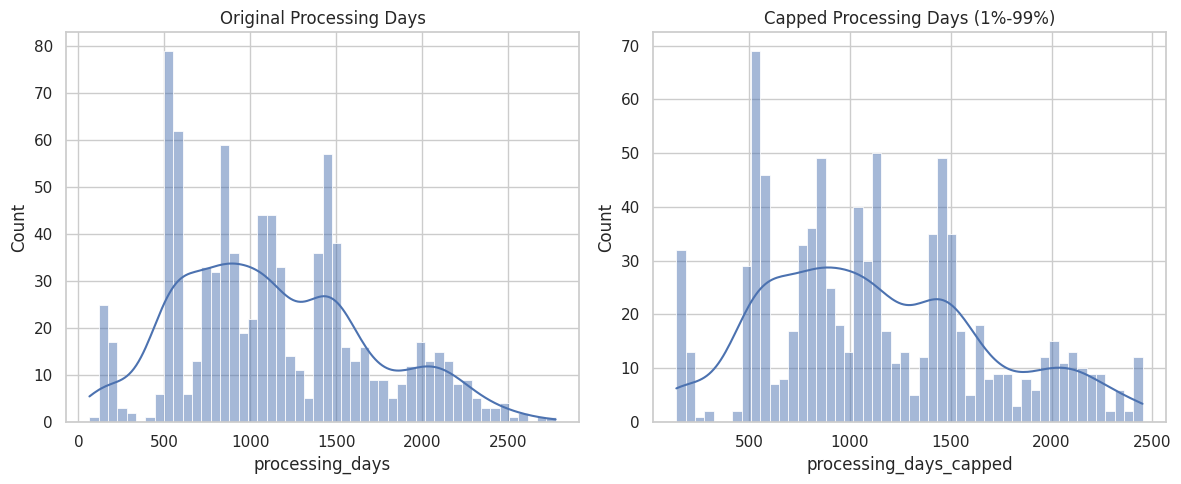

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["processing_days"], bins=50, kde=True)
plt.title("Original Processing Days")

plt.subplot(1,2,2)
sns.histplot(df["processing_days_capped"], bins=50, kde=True)
plt.title("Capped Processing Days (1%-99%)")

plt.tight_layout()
plt.show()

In [ ]:
print("Old Max:", df["processing_days"].max())
print("New Max:", df["processing_days_capped"].max())

Old Max: 2778
New Max: 2451.0


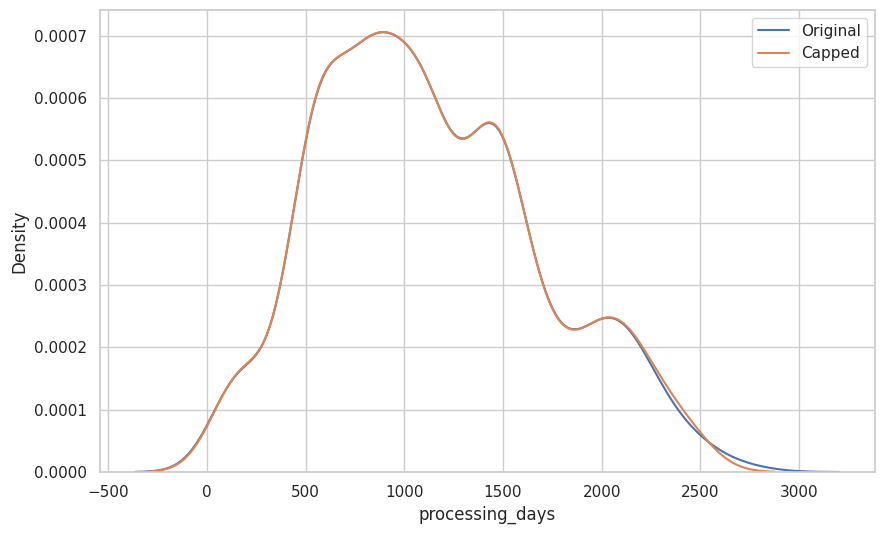

In [ ]:
sns.kdeplot(df["processing_days"], label="Original")
sns.kdeplot(df["processing_days_capped"], label="Capped")
plt.legend()
plt.show()

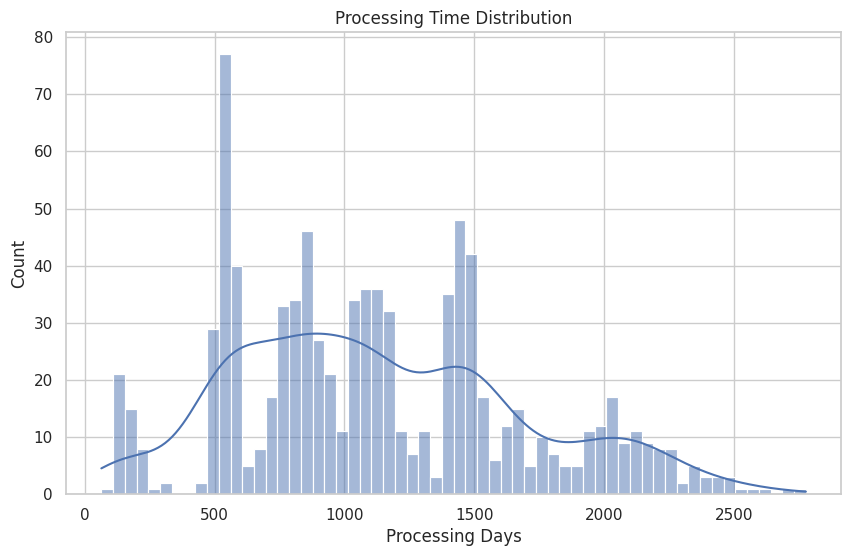

In [ ]:
sns.histplot(df["processing_days"], bins=60, kde=True)
plt.title("Processing Time Distribution")
plt.xlabel("Processing Days")
plt.show()

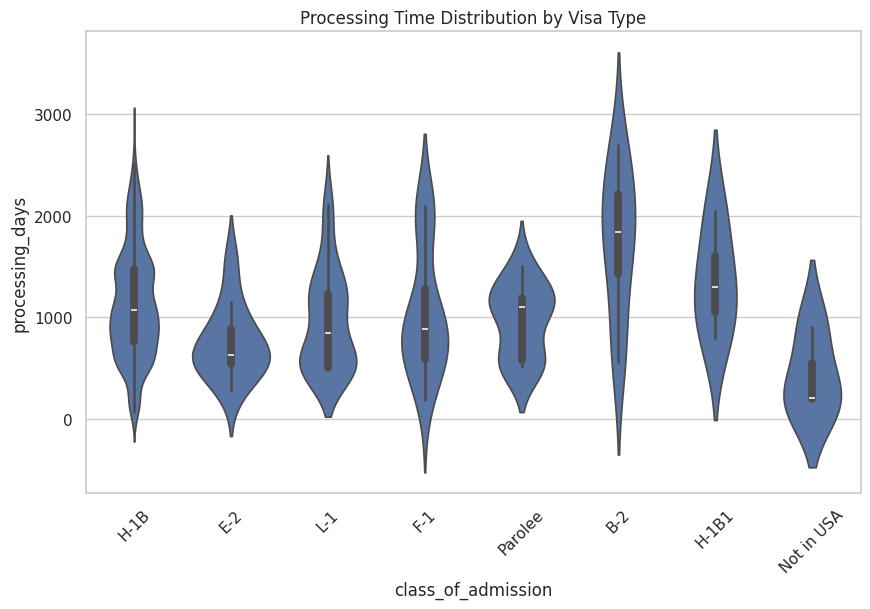

In [ ]:
top_visa = df["class_of_admission"].value_counts().head(8).index
df_top = df[df["class_of_admission"].isin(top_visa)]

sns.violinplot(
    data=df_top,
    x="class_of_admission",
    y="processing_days"
)

plt.xticks(rotation=45)
plt.title("Processing Time Distribution by Visa Type")
plt.show()

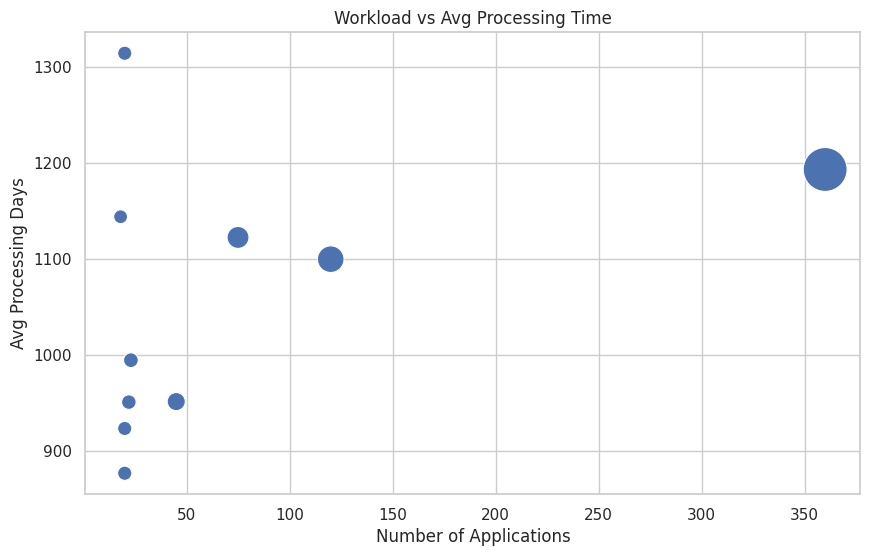

In [ ]:
state_stats = df.groupby("employer_state").agg({
    "processing_days": "mean",
    "case_status": "count"
}).reset_index()

state_stats = state_stats.sort_values("case_status", ascending=False).head(10)

sns.scatterplot(
    data=state_stats,
    x="case_status",
    y="processing_days",
    size="case_status",
    sizes=(100,1000),
    legend=False
)

plt.title("Workload vs Avg Processing Time")
plt.xlabel("Number of Applications")
plt.ylabel("Avg Processing Days")
plt.show()

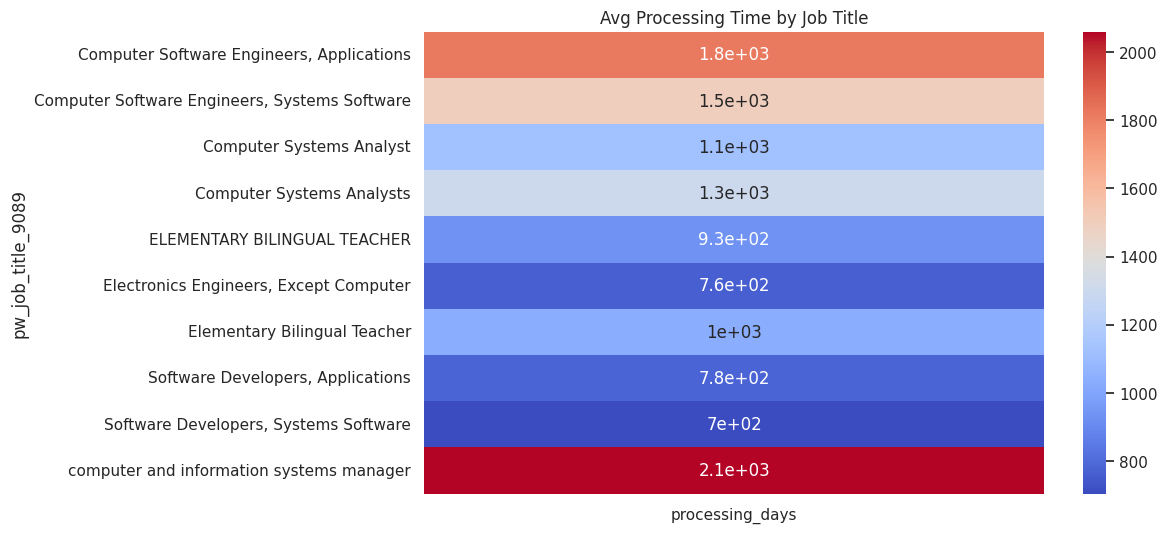

In [ ]:
top_industries = df["pw_job_title_9089"].value_counts().head(10).index
df_ind = df[df["pw_job_title_9089"].isin(top_industries)]

industry_avg = df_ind.groupby("pw_job_title_9089")["processing_days"].mean()

sns.heatmap(
    industry_avg.to_frame(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Avg Processing Time by Job Title")
plt.show()

In [ ]:
df["month"] = df["case_received_date"].dt.month
df["year"] = df["case_received_date"].dt.year
df["quarter"] = df["case_received_date"].dt.quarter

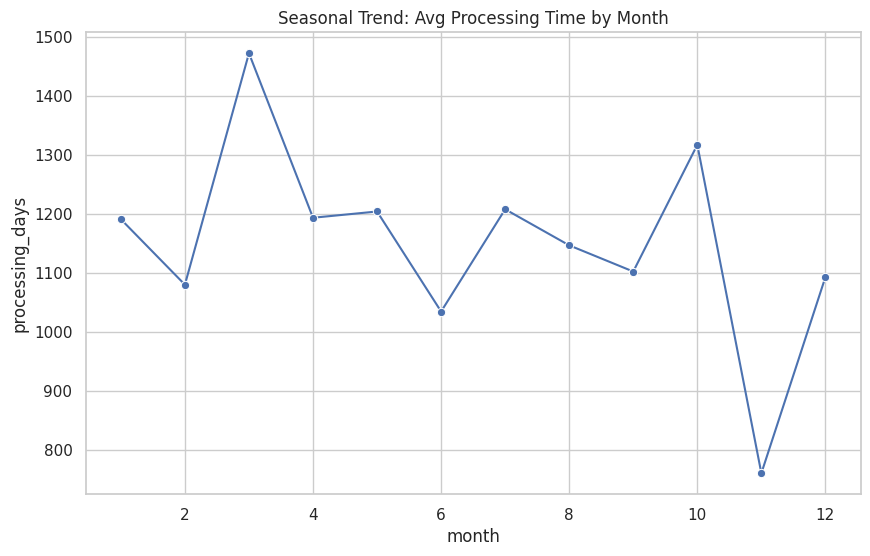

In [ ]:
month_avg = df.groupby("month")["processing_days"].mean().reset_index()

sns.lineplot(data=month_avg, x="month", y="processing_days", marker="o")
plt.title("Seasonal Trend: Avg Processing Time by Month")
plt.show()

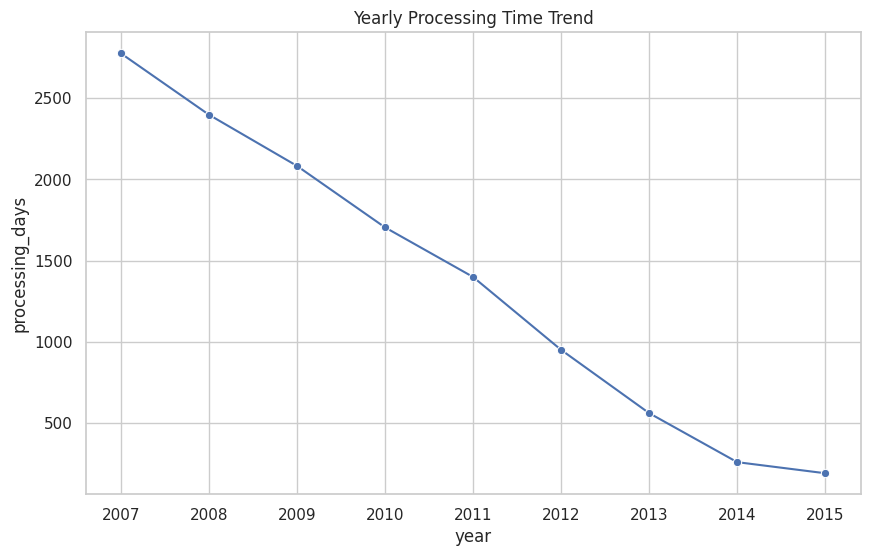

In [ ]:
year_avg = df.groupby("year")["processing_days"].mean().reset_index()

sns.lineplot(data=year_avg, x="year", y="processing_days", marker="o")
plt.title("Yearly Processing Time Trend")
plt.show()

In [ ]:
if "case_received_date" in df.columns:
    df["filing_year"] = df["case_received_date"].dt.year
    df["filing_month"] = df["case_received_date"].dt.month
    df["filing_quarter"] = df["case_received_date"].dt.quarter

In [ ]:
if "employer_yr_estab" in df.columns:
    df["employer_age"] = (
        df["case_received_date"].dt.year - df["employer_yr_estab"]
    )

In [ ]:
if "filing_year" in df.columns and "filing_month" in df.columns:
    monthly_volume = df.groupby(["filing_year","filing_month"]).size().reset_index(name="monthly_volume")
    df = df.merge(monthly_volume, on=["filing_year","filing_month"], how="left")

In [ ]:
if "pw_amount_9089" in df.columns:
    df["wage_log"] = np.log1p(df["pw_amount_9089"])

In [ ]:
if "country_of_citizenship" in df.columns:
    country_freq = df["country_of_citizenship"].value_counts()
    df["country_frequency"] = df["country_of_citizenship"].map(country_freq)

In [ ]:
if "naics_title" in df.columns:
    industry_avg = df.groupby("naics_title")["processing_days"].mean()
    df["industry_avg_processing"] = df["naics_title"].map(industry_avg)

In [ ]:
print("New Columns Created:")
print(df.columns)

New Columns Created:
Index(['case_received_date', 'case_status', 'class_of_admission',
       'country_of_citizenship', 'decision_date', 'employer_city',
       'employer_country', 'employer_name', 'employer_state',
       'foreign_worker_info_birth_country', 'job_info_education',
       'pw_determ_date', 'pw_expire_date', 'pw_job_title_9089',
       'processing_days', 'pwd_to_filing_days', 'case_status_binary',
       'filing_year', 'filing_month', 'filing_quarter', 'monthly_volume',
       'country_frequency'],
      dtype='object')


In [ ]:
df.describe()

,case_received_date,decision_date,pw_determ_date,processing_days,pwd_to_filing_days,case_status_binary,filing_year,filing_month,filing_quarter,monthly_volume,country_frequency
count,881,881,881,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,2012-02-16 17:08:06.265607168,2015-03-23 18:20:01.362088704,2011-09-07 14:16:28.876276992,1131.049943,162.119183,0.289444,2011.570942,7.174801,2.695800,33.558456,357.921680
min,2007-09-04 00:00:00,2014-10-02 00:00:00,2006-06-05 00:00:00,64.000000,1.000000,0.000000,2007.000000,1.000000,1.000000,1.000000,1.000000
25%,2011-03-21 00:00:00,2014-12-23 00:00:00,2010-08-24 00:00:00,728.000000,89.000000,0.000000,2011.000000,5.000000,2.000000,9.000000,29.000000
50%,2012-06-20 00:00:00,2015-04-13 00:00:00,2012-01-18 00:00:00,1065.000000,135.000000,0.000000,2012.000000,7.000000,3.000000,27.000000,556.000000
75%,2012-11-08 00:00:00,2015-05-28 00:00:00,2012-08-15 00:00:00,1477.000000,204.000000,1.000000,2012.000000,10.000000,4.000000,48.000000,556.000000
max,2015-06-30 00:00:00,2015-09-29 00:00:00,2015-02-11 00:00:00,2778.000000,1220.000000,1.000000,2015.000000,12.000000,4.000000,87.000000,556.000000
std,NaN,NaN,NaN,552.624229,116.355180,0.453762,1.453763,3.002098,1.029383,27.564619,259.384073
